## Univariate Regression - Ontario and California Housing Data

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from IPython.display import display, Markdown
np.random.seed(42)

In [ ]:
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"

california_df = pd.read_csv(raw_dir / "california_housing.csv")
ontario_df = pd.read_csv(raw_dir / "ontario_housing_2024.csv")

print(f"California rows: {len(california_df)}")
print(f"Ontario rows: {len(ontario_df)}")
print("\nCalifornia columns:", list(california_df.columns))
print("Ontario columns:", list(ontario_df.columns))

california_df.head()
ontario_df.head()

California rows: 20640
Ontario rows: 51

California columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Ontario columns: ['_id', 'Municipality', 'Ten-year housing target', 'Total housing progress since 2022', 'Target for 2024', 'Total 2024 housing progress', 'Progress % for 2024', 'Housing target status']


,_id,Municipality,Ten-year housing target,Total housing progress since 2022,Target for 2024,Total 2024 housing progress,Progress % for 2024,Housing target status
0,1,Ajax,17000,1908,1417,270,19.05%,Not met
1,2,Aurora,8000,663,667,189,28.34%,Not met
2,3,Barrie,23000,5450,1917,1459,76.11%,Not met
3,4,Belleville,3100,1177,258,250,96.90%,On track
4,5,Bradford West Gwillimbury,6500,1015,542,263,48.52%,Not met


In [23]:
california_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   households          20640 non-null  float64
 4   median_income       20640 non-null  float64
 5   median_house_value  20640 non-null  float64
 6   ocean_proximity     20640 non-null  str    
 7   avg_bedrooms        20640 non-null  float64
 8   avg_occupancy       20640 non-null  float64
dtypes: float64(8), str(1)
memory usage: 1.4 MB


## Visualize the Raw Data
#### Visualize the raw data using a scatter plot. Draw the line of best fit. First, we limited the average rooms to records with values less than 12. 

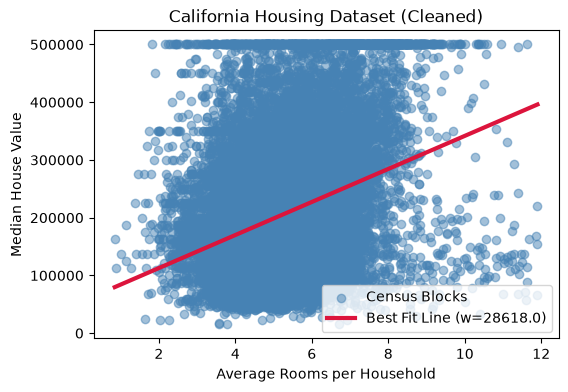

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the average number of rooms per individual house
california_df['avg_bedrooms'] = california_df['total_rooms'] / california_df['households']

# Calculate the average number of people living in each house
california_df['avg_occupancy'] = california_df['population'] / california_df['households']

# Drop the old, confusing cumulative columns
california_df = california_df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])

# Filter out the extreme room outliers so the line isn't warped
cali_df_cleaned = california_df[california_df['avg_bedrooms'] < 12]

# 2. Extract your X and Y values from the cleaned data
x = cali_df_cleaned['avg_bedrooms'].values
y = cali_df_cleaned['median_house_value'].values
n = len(x)

# 3. Run your analytical solution (Normal Equation) on the clean data
X_design = np.vstack([x, np.ones(n)]).T
theta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
w_hat, b_hat = theta

# 4. Initialize the plot
plt.figure(figsize=(6,4))
# alpha=0.5 makes dense points semi-transparent so you can see the cluster density
plt.scatter(x, y, c='steelblue', alpha=0.5, label='Census Blocks')

# 5. Generate points to draw the line of best fit
x_line = np.linspace(x.min(), x.max(), 100)
y_line = w_hat * x_line + b_hat

# 6. Draw the line on top of the scatter plot
plt.plot(x_line, y_line, color='crimson', linewidth=3, label=f'Best Fit Line (w={w_hat:.1f})')

# 7. Add labels, legend, and render
plt.xlabel('Average Rooms per Household')
plt.ylabel('Median House Value')
plt.title('California Housing Dataset (Cleaned)')
plt.legend()
plt.show()